# **1. Mount & Extract**

In [ ]:
from google.colab import drive
from pathlib import Path
import zipfile

drive.mount("/content/drive")

ZIP_PATH     = Path("/content/drive/MyDrive/Betta_Classification/dataset_clean.zip")
EXTRACT_PATH = Path("/content/dataset")
BASE_DIR     = EXTRACT_PATH / "dataset_clean"

if not BASE_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_PATH)

print("Extraction complete. Classes found:", [d.name for d in BASE_DIR.iterdir() if d.is_dir()])

Mounted at /content/drive
Extraction complete. Classes found: ['Plakat', 'Double_Tail', 'Veiltail']


# **2. Stratified Split**

In [ ]:
!pip install split-folders -q

import splitfolders

OUTPUT_DIR = Path("/content/dataset_split")

splitfolders.ratio(
    str(BASE_DIR),
    output=str(OUTPUT_DIR),
    seed=42,
    ratio=(0.70, 0.15, 0.15),
)

for split in ("train", "val", "test"):
    split_path = OUTPUT_DIR / split
    total = sum(len(files) for _, _, files in split_path.walk())
    print(f"  {split.upper():<5}  {total} images")

Copying files: 300 files [00:00, 1617.76 files/s]

  TRAIN  210 images
  VAL    45 images
  TEST   45 images


# **3. Data Pipeline**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE


def build_dataset(directory: str, training: bool) -> tuple[tf.data.Dataset, list[str]]:
    """
    Build a tf.data pipeline with MobileNetV3-compatible preprocessing.

    Args:
        directory: Path to the split directory (train / val / test).
        training:  If True, applies augmentation and shuffles.

    Returns:
        Tuple of (prefetched dataset, class_names list).
        class_names must be extracted here — attribute lost after prefetch wrapping.
    """
    raw_ds = tf.keras.utils.image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=training,
        seed=42,
        label_mode="categorical",
    )

    # Extract before any chaining — attribute unavailable on _PrefetchDataset
    class_names = raw_ds.class_names
    ds = raw_ds

    if training:
        augment = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.10),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomTranslation(0.08, 0.08),
            # Brightness/contrast shift forces the model to rely on shape not color
            tf.keras.layers.RandomBrightness(0.15),
            tf.keras.layers.RandomContrast(0.15),
        ])
        ds = ds.map(
            lambda x, y: (augment(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )

    # MobileNetV3 requires pixel values scaled to [-1, 1] via preprocess_input
    ds = ds.map(
        lambda x, y: ((x / 127.5) - 1.0, y),
        num_parallel_calls=AUTOTUNE,
    )
    return ds.prefetch(AUTOTUNE), class_names


train_ds, class_names = build_dataset(str(OUTPUT_DIR / "train"), training=True)
val_ds,   _           = build_dataset(str(OUTPUT_DIR / "val"),   training=False)
test_ds,  _           = build_dataset(str(OUTPUT_DIR / "test"),  training=False)

print("Class mapping:", class_names)

Found 210 files belonging to 3 classes.
Found 45 files belonging to 3 classes.
Found 45 files belonging to 3 classes.
Class mapping: ['Double_Tail', 'Plakat', 'Veiltail']


# **4. Model Architecture**

In [ ]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

NUM_CLASSES = len(class_names)

base_model = MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3),
    include_preprocessing=False,  # disable internal rescaling; handled by pipeline
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(64, activation="relu")(x)  # bottleneck reduces overfitting on small dataset
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary(line_length=80)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7         │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv (Conv2D)         │ (None, 112, 112,  │         432 │ input_layer_7[0][… │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv_bn               │ (None, 112, 112,  │          64 │ conv[0][0]         │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_72         │ (None, 112, 112,  │           0 │ conv_bn[0][0]      │
│ (Activation)          │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 113, 113,  │           0 │ activation_72[0][… │
│ (ZeroPadding2D)       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 56, 56,    │         144 │ expanded_conv_dep… │
│ (DepthwiseConv2D)     │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_depthw… │ (None, 56, 56,    │          64 │ expanded_conv_dep… │
│ (BatchNormalization)  │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_56 (ReLU)       │ (None, 56, 56,    │           0 │ expanded_conv_dep… │
│                       │ 16)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_squeez… │ (None, 1, 1, 16)  │           0 │ re_lu_56[0][0]     │
│ (GlobalAveragePoolin… │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_squeez… │ (None, 1, 1, 8)   │         136 │ expanded_conv_squ… │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_squeez… │ (None, 1, 1, 8)   │           0 │ expanded_conv_squ… │
│ (ReLU)                │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_squeez… │ (None, 1, 1, 16)  │         144 │ expanded_conv_squ… │
│ (Conv2D)              │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add_36 (Add)          │ (None, 1, 1, 16)  │           0 │ expanded_conv_squ… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_57 (ReLU)       │ (None, 1, 1, 16)  │           0 │ add_36[0][0]       │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ multiply_36           │ (None, 1, 1, 16)  │           0 │ re_lu_57[0][0]     │
│ (Multiply)            │                   │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_squeez… │ (None, 56, 56,    │           0 │ re_lu_56[0][0],    │
│ (Multiply)            │ 16)               │             │ multiply_36[0][0]  │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ expanded_conv_project │ (None

 Total params: 976,243 (3.72 MB)

 Trainable params: 37,123 (145.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
# Run this before Phase 1
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small

base = MobileNetV3Small(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
print(base.layers[1].name)  # Should print 'rescaling' if internal preprocessing exists

rescaling_3


# **5. Classifier Warmup**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CHECKPOINT_PATH = "/content/models/01_mobilenetv3.keras"

print("\nPHASE 1: Classifier head warmup — base model frozen")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

# Warmup phase is short; early stopping protects against head overfitting
warmup_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
]

history_warmup = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=warmup_callbacks,
    verbose=1,
)


PHASE 1: Classifier head warmup — base model frozen
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.3714 - loss: 1.3626 - val_accuracy: 0.6444 - val_loss: 0.8480
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 977ms/step - accuracy: 0.5476 - loss: 0.9573 - val_accuracy: 0.8000 - val_loss: 0.6210
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 816ms/step - accuracy: 0.6714 - loss: 0.7717 - val_accuracy: 0.8444 - val_loss: 0.5359
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 919ms/step - accuracy: 0.7667 - loss: 0.6122 - val_accuracy: 0.8667 - val_loss: 0.4733
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 792ms/step - accuracy: 0.8571 - loss: 0.4463 - val_accuracy: 0.8667 - val_loss: 0.3794
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 951ms/step - accuracy: 0.8381 - loss: 0.4641 - val_accuracy: 0.8667 - val_loss: 0.3313
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 785ms/step - accuracy: 0.8429 - loss: 0.4107 - val_accuracy: 0.9111 - val_loss: 0.2905
Epoch 8/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8524 -

# **6. Fine-Tuning**

In [ ]:
print("\nPHASE 2: Fine-tuning top convolutional layers")
base_model.trainable = True

# Freeze all layers except the top 30 — deeper layers encode generic ImageNet
# features (edges, textures); top layers encode domain-specific morphology
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in model.layers if l.trainable)}/{len(model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

finetune_callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ModelCheckpoint(CHECKPOINT_PATH, monitor="val_accuracy", save_best_only=True, mode="max"),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-7, verbose=1),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=finetune_callbacks,
    verbose=1,
)


PHASE 2: Fine-tuning top convolutional layers
Trainable layers: 34/160
Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.8238 - loss: 0.4447 - val_accuracy: 0.9778 - val_loss: 0.1545 - learning_rate: 1.0000e-05
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 831ms/step - accuracy: 0.8619 - loss: 0.3718 - val_accuracy: 0.9778 - val_loss: 0.1536 - learning_rate: 1.0000e-05
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 935ms/step - accuracy: 0.8095 - loss: 0.4442 - val_accuracy: 0.9778 - val_loss: 0.1540 - learning_rate: 1.0000e-05
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 797ms/step - accuracy: 0.8381 - loss: 0.4205 - val_accuracy: 0.9778 - val_loss: 0.1548 - learning_rate: 1.0000e-05
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 881ms/step - accuracy: 0.8571 - loss: 0.3884 - val_accuracy: 0.9778 - val_loss: 0.1560 - learning_rate: 1.0000e-05
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.8667 - loss: 0.3761 - val_accuracy: 0.9778 - val_loss: 0.1574 - learning_rate: 1.0000e-05
Epoch 7/

# **7. Training Curve**

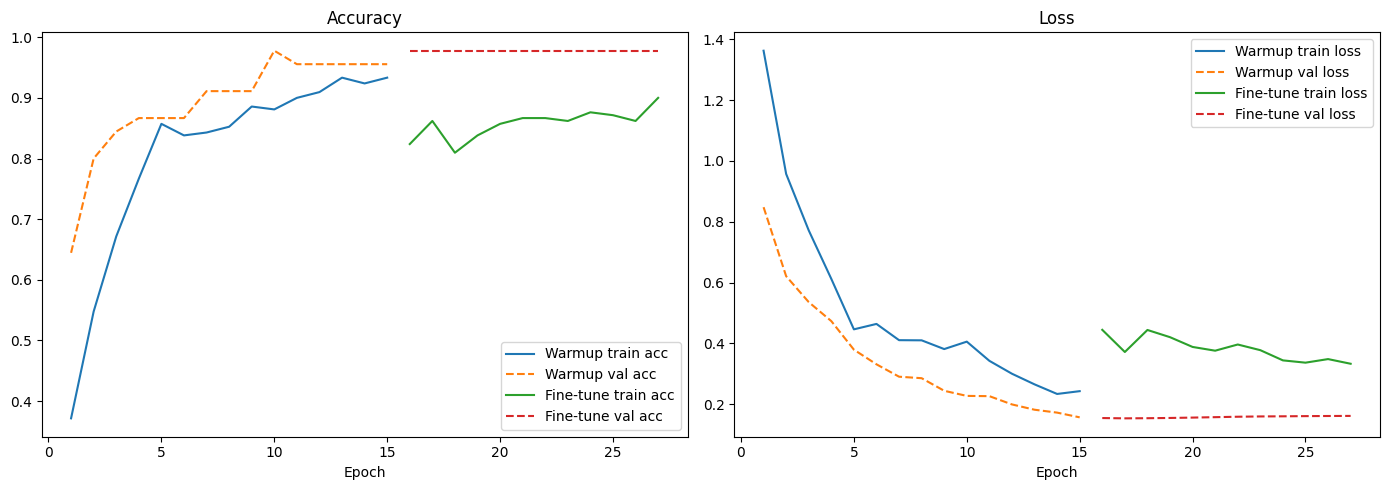

In [ ]:
import matplotlib.pyplot as plt

def plot_history(histories: list, labels: list) -> None:
    """Plot combined accuracy and loss curves across training phases."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    offset = 0
    for hist, label in zip(histories, labels):
        epochs = range(offset + 1, offset + len(hist.history["accuracy"]) + 1)
        axes[0].plot(epochs, hist.history["accuracy"],     label=f"{label} train acc")
        axes[0].plot(epochs, hist.history["val_accuracy"], label=f"{label} val acc",   linestyle="--")
        axes[1].plot(epochs, hist.history["loss"],         label=f"{label} train loss")
        axes[1].plot(epochs, hist.history["val_loss"],     label=f"{label} val loss",  linestyle="--")
        offset += len(hist.history["accuracy"])

    axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].set_xlabel("Epoch")
    axes[1].set_title("Loss");     axes[1].legend(); axes[1].set_xlabel("Epoch")
    plt.tight_layout()
    plt.savefig("/content/results/01_training_curves.png", dpi=150)
    plt.show()

plot_history([history_warmup, history_finetune], ["Warmup", "Fine-tune"])

# **8. Evaluation**


Test set benchmark (best checkpoint weights)
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9111 - loss: 0.2045

  Test Accuracy : 91.11%
  Test Loss     : 0.2045
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 5s/step

Classification Report
              precision    recall  f1-score   support

 Double_Tail      0.929     0.867     0.897        15
      Plakat      0.824     0.933     0.875        15
    Veiltail      1.000     0.933     0.966        15

    accuracy                          0.911        45
   macro avg      0.917     0.911     0.912        45
weighted avg      0.917     0.911     0.912        45



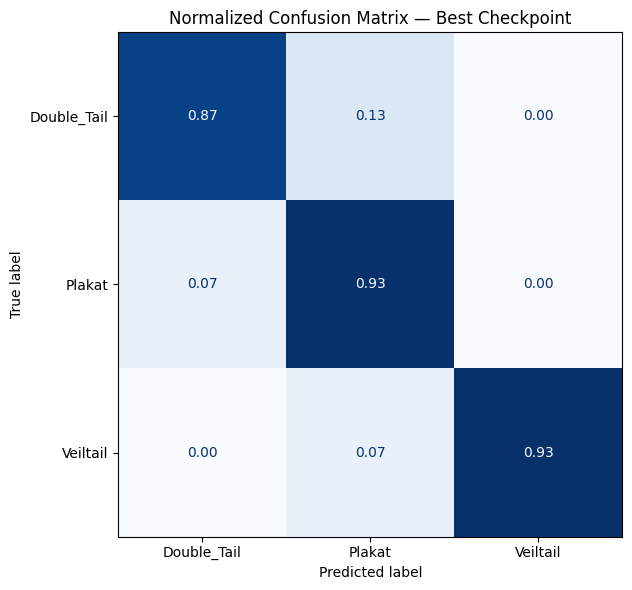

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Load best weights — evaluates the checkpoint, not the last epoch
best_model = tf.keras.models.load_model(CHECKPOINT_PATH)

print("\nTest set benchmark (best checkpoint weights)")
test_loss, test_acc = best_model.evaluate(test_ds, verbose=1)
print(f"\n  Test Accuracy : {test_acc * 100:.2f}%")
print(f"  Test Loss     : {test_loss:.4f}")

# Rebuild ground-truth labels from the unshuffled test dataset
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

y_prob = best_model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

# Normalized confusion matrix reveals per-class recall at a glance
cm = confusion_matrix(y_true, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
ax.set_title("Normalized Confusion Matrix — Best Checkpoint")
plt.tight_layout()
plt.savefig("/content/results/01_confusion_matrix.png", dpi=150)
plt.show()

# **9. Export**

In [ ]:
TFLITE_PATH = "/content/models/01_mobilenetv3_f16.tflite"

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

with open(TFLITE_PATH, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 ** 2)
print(f"TFLite model exported: {TFLITE_PATH}  ({size_mb:.2f} MB)")

Saved artifact at '/tmp/tmptoiz58c0'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132994887319376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835793296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835793488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994887319184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835792336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835791952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835793104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835792912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835792720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132994835794448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1329948357938

# **10. Download**

In [ ]:
from google.colab import files
import os

os.makedirs("/content/models",  exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

files.download("/content/models/01_mobilenetv3.keras")
files.download("/content/models/01_mobilenetv3_f16.tflite")
files.download("/content/results/01_training_curves.png")
files.download("/content/results/01_confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>